In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

In [2]:
from GraphSimulation import (
    TripartiteGraph,
    MatchingStrategy, 
    RandomStrategy, 
    GreedyStrategy, 
    RankStrategy, 
    TimeSeriesStrategy
)

In [3]:
n_Inodes = 100
n_Lnodes = 100
n_Rnodes = 100

OPTIMAL = min(n_Lnodes, n_Inodes, n_Rnodes)

In [4]:
def generate_varNodes(inode_ids, n_Lnodes, n_Inodes, n_Rnodes, shuffle=False, seed= None):
    rand_gen = np.random.default_rng(seed)
    nodes = []

    # Generate L nodes
    for _ in range(n_Lnodes):
        k = rand_gen.integers(1, n_Inodes + 1)
        candidates = rand_gen.choice(inode_ids, size=k, replace=False).tolist()
        nodes.append(("L", candidates))

    # Generate R nodes
    for _ in range(n_Rnodes):
        k = rand_gen.integers(1, n_Inodes + 1)
        candidates = rand_gen.choice(inode_ids, size=k, replace=False).tolist()
        nodes.append(("R", candidates))

    if shuffle: rand_gen.shuffle(nodes)
    return nodes

def simulate_online(graph: TripartiteGraph, node_order):
    for time, (node_type, candidates) in enumerate(node_order):
        if node_type == "L":
            graph.add_Lnode(time, candidates)
        else:
            graph.add_Rnode(time, candidates)
    return graph.matches

In [5]:
def run_experiment(strategy: MatchingStrategy, runs=100, 
                n_inodes= n_Inodes, n_lnodes=n_Lnodes, n_rnodes=n_Rnodes, 
                seed:int|None= None):
    results_online = []
    rand_gen = np.random.default_rng(seed)

    # Create the Graph
    g = TripartiteGraph(strategy, n_inodes)
    inode_ids = list(g.Inodes.keys())

    # Generate the nodes order
    node_order = generate_varNodes(inode_ids,
                        n_lnodes, n_inodes, n_rnodes, seed=seed)

    pbar = tqdm(range(runs), desc=f'Simulating: {strategy.name}')
    for _ in pbar:
        # Shuffle Nodes
        rand_gen.shuffle(node_order)

        # Online
        matches_online = simulate_online(g, node_order)
        results_online.append(matches_online)

        # Reset Graph
        g.reset()
    return results_online

In [6]:
RUN_SEED = 42
results = {}

results['Random'] = run_experiment(RandomStrategy(), seed= RUN_SEED)
results['Greedy'] = run_experiment(GreedyStrategy(), seed= RUN_SEED)
results['Rank'] = run_experiment(RankStrategy(), seed= RUN_SEED)

model_strategy = TimeSeriesStrategy()
model_strategy.eval()

results['TimeSeries'] = run_experiment(model_strategy, seed= RUN_SEED)

Simulating: RandomStrategy:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating: TimeSeriesStrategy: 100%|██████████| 100/100 [02:00<00:00,  1.21s/it]


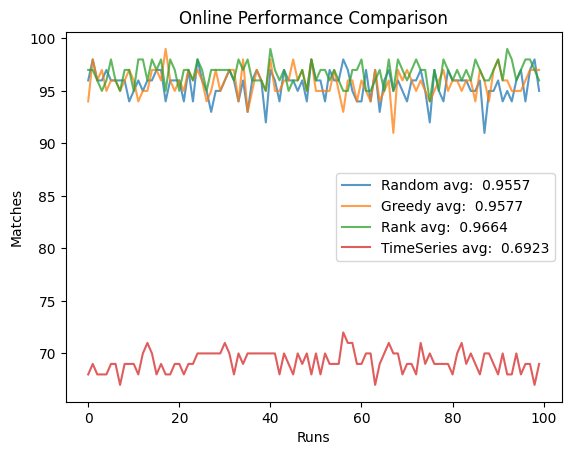

In [7]:
def plot_results(results, optimal= OPTIMAL):
    for res in results:
        plt.plot(results[res], alpha=0.75, label=f"{res} avg: {np.average(results[res]) / optimal: .4f}")

    plt.title("Online Performance Comparison")
    plt.xlabel("Runs")
    plt.ylabel("Matches")

    plt.legend()
    plt.show()

plot_results(results)